#Deep Learning Text Generation using RNN, LSTM and GRU
#Objective
The objective of this project is to design and implement deep learning models capable of learning grammar, contextual dependencies, and sequential patterns from text data to generate meaningful text sequences.

*   The project compares the perfomance of :
*   Vanilla RNN
*   LSTM
*   GRU
*   for the next-word prediction and text generation tasks








#Step 1 : Problem Statement
Design and implement a Deep Learning model capable of learning the underlyimg structure, grammar, and contextual dependencies of a given text corpus to generate coherant and meaningful text sequences using :

*   Vanilla RNN
*   LSTM
*   GRU
#The models are compared based on :
*   Training Loss
*   Generated Text Quality
*   Memory Handling Capability and Long-Term Dependency learning

The objective is to analyze how different recurrent architectures learn sequential patterns and generate contextually relevant text.









#Step 2 : Import Required Libraries
The following libraries are used for text processing, tokenization, sequence creation, deep learning model development, training and visualization.

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("Tensorflow Version", tf.__version__)

Tensorflow Version 2.20.0


#Step 3 : Load Custom Text Corpus
A custom Artificial Intelligence and Deep Learning corpus is used instead of default sample corpus. This enables the models to learn domain-specific vocabulary, contextual relationships, and sequential patterns relevant to modern AI applications.

In [2]:
corpus = """
artificial intelligence is transforming industries across the world
machine learning enables systems to learn from historical data
deep learning models identify hidden patterns in large datasets
recurrent neural networks are widely used for sequential learning
lstm networks overcome long term dependency problems
gru networks provide efficient memory management mechanisms
natural language processing enables computers to understand and generate human language
transformer architectures have revolutionized modern ai systems
bert and gpt are powerful transformer based language models
generative ai applications are transforming business and education
data science combines statistics programming and domain expertise
large language models can generate meaningful text sequences
sequence models learn relationships between words and sentences
deep learning algorithms require large amounts of training data
responsible artificial intelligence focuses on fairness transparency and trust
"""


In [3]:
print(corpus)


artificial intelligence is transforming industries across the world
machine learning enables systems to learn from historical data
deep learning models identify hidden patterns in large datasets
recurrent neural networks are widely used for sequential learning
lstm networks overcome long term dependency problems
gru networks provide efficient memory management mechanisms
natural language processing enables computers to understand and generate human language
transformer architectures have revolutionized modern ai systems 
bert and gpt are powerful transformer based language models 
generative ai applications are transforming business and education
data science combines statistics programming and domain expertise
large language models can generate meaningful text sequences
sequence models learn relationships between words and sentences
deep learning algorithms require large amounts of training data
responsible artificial intelligence focuses on fairness transparency and trust



In [4]:
corpus = corpus.lower()
corpus = corpus.strip()
print(corpus)

artificial intelligence is transforming industries across the world
machine learning enables systems to learn from historical data
deep learning models identify hidden patterns in large datasets
recurrent neural networks are widely used for sequential learning
lstm networks overcome long term dependency problems
gru networks provide efficient memory management mechanisms
natural language processing enables computers to understand and generate human language
transformer architectures have revolutionized modern ai systems 
bert and gpt are powerful transformer based language models 
generative ai applications are transforming business and education
data science combines statistics programming and domain expertise
large language models can generate meaningful text sequences
sequence models learn relationships between words and sentences
deep learning algorithms require large amounts of training data
responsible artificial intelligence focuses on fairness transparency and trust


#Step 4 : Tokenization and Sequence Creation
The text corpus is converted into numerical representations using tokenization. Progressive n-gram sequences are then generated to enable next-word prediction during training

In [5]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])
total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)
input_sequences = []
for line in corpus.split('\n'):
  token_list = tokenizer.texts_to_sequences([line])[0]
  for i in range(1, len(token_list)):
    n_gram_seq = token_list[:i+1]
    input_sequences.append(n_gram_seq)
max_len = max(len(seq) for seq in input_sequences)
input_sequences = np.array(pad_sequences(input_sequences, maxlen=max_len, padding='pre'))
X = input_sequences[:, :-1]
y = input_sequences[:, -1]
print("X shape:", X.shape)
print("y shape:", y.shape)


Vocabulary size: 94
X shape: (111, 10)
y shape: (111,)


#Step 5 : Vanilla RNN
Vanilla Recurrent Neural Networks (RNNs) are designed for sequential data processing. However, they often struggle with long-term dependencies due to vanishing gradient problem during Backpropagation Through Time(BPTT).

In [6]:
rnn_model = Sequential([
  (Embedding(total_words, 128)),
  (SimpleRNN(128)),
  (Dense(total_words, activation='softmax'))
])
rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
rnn_history = rnn_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)
print("Vanilla RNN Training Completed")

Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 340ms/step - accuracy: 0.0090 - loss: 4.5459
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1171 - loss: 4.4082 
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0811 - loss: 4.3017 
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0901 - loss: 4.1930 
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1261 - loss: 4.0862 
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1532 - loss: 3.9655
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1532 - loss: 3.8476 
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1802 - loss: 3.7285 
Epoch 9/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1532 - loss: 3.5942 
Epoch 10/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2703 - loss: 3.4419 
Epoch 11/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4324 - loss: 3.2919
Epoch 12/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4865 - l

#Observation
The Vanilla RNN successfully learned sequential patterns from the training corpus and achieved a training accuracy of approximatley 99.10% with a loss of 0.0214. However , despite its strong perfomance on the training data, Vanilla RNNs are generally limited in handling long-term dependencies due to the vanishing gradient problem.

#Step 6 - LSTM
Long Short-Term Memory (LSTM) networks address the limitations of Vanilla RNNs through Forget, Input, and Output Gates. These gates enable the model to retain relevant information over long sewuences and ignore contextual understanding.

In [7]:
lstm_model = Sequential([
    Embedding(total_words, 128),
    LSTM(128),
    Dense(total_words, activation='softmax')
])
lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
lstm_history = lstm_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)
print("LSTM Training Completed")

Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.0090 - loss: 4.5432
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0450 - loss: 4.5235
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0541 - loss: 4.4972    
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0450 - loss: 4.4668
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0360 - loss: 4.3798    
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0360 - loss: 4.3186    
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0360 - loss: 4.3040
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0631 - loss: 4.2581    
Epoch 9/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0991 - loss: 4.2191
Epoch 10/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0721 - loss: 4.1875
Epoch 11/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0721 - loss: 4.1476
Epoch 12/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accur

#Observation
The LSTM model successfully learned long-term contextual dependencies and achieved a training accuracy of approximately 99.10% with a loss of 0.0521. The gating mechanisms, including the Forget, Input, and Output Gates, enabled effective information retention and stable sequence learning throughout training.

#Step 7 - GRU
The Gated Recurrent Unit (GRU) is a simpified variant of LSTM that uses Update and Reset Gates to control information flow.GRU often achieves perfomance comparable to LSTM while requiring fewer paramters and reduced computational complexity.

In [8]:
gru_model = Sequential([
    Embedding(total_words, 128),
    GRU(128),
    Dense(total_words, activation='softmax')
])
gru_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
gru_history = gru_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)
print("GRU Training Completed")

Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.0270 - loss: 4.5447
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1261 - loss: 4.5184
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1441 - loss: 4.4932
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1441 - loss: 4.4624
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1441 - loss: 4.4146
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0631 - loss: 4.3370
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0541 - loss: 4.2492
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0811 - loss: 4.2046
Epoch 9/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1261 - loss: 4.1428 
Epoch 10/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1351 - loss: 4.0940
Epoch 11/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1441 - loss: 4.0293
Epoch 12/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1532 - l

#Observation
The GRU model effectively learned the sequential patterns present in the corpus and achievd a training accuracy of approximately 99.10% with a loss of 0.0223. By utilising Update and Reset Gates, GRU effectively captured contextual dependencies while maintaining a simple architecture compared to LSTM.


#Step 8 - Training Loss Comparison
The training loss curves of Vanilla RNN, LSTM, and GRU are compared to evaluate their convergence behavior and learning efficiency during training.

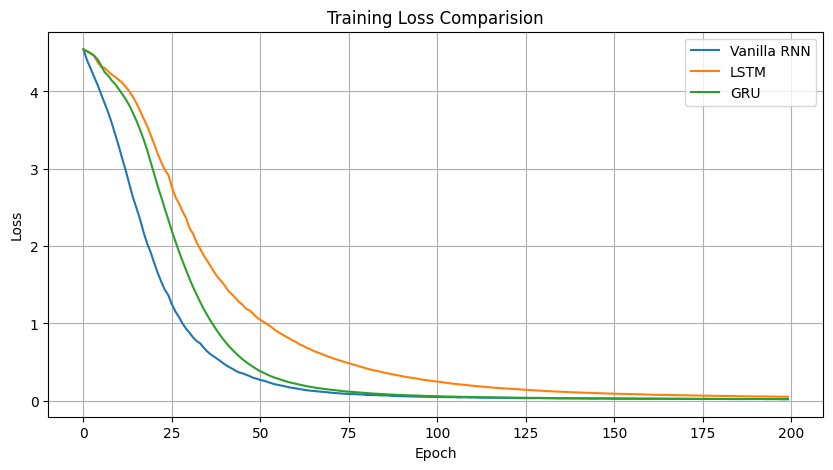

In [9]:
plt.figure(figsize=(10,5))
plt.plot(rnn_history.history['loss'], label='Vanilla RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparision")
plt.legend()
plt.grid(True)
plt.show()

#Observation
The training loss curves indicate that all three models successfully learned the sequential patterns present in the corpus. Vanilla RNN achieved the fastest convergence and the lowest final loss, while GRU demonstrated comparable performance with a slightly higher loss. LSTM required more epochs to converge and maintained a higher loss throughout training. Since the dataset is relatively small, all three models achieved similar training accuracy, although their convergence behaviors differed.

#Step 9 - Text Generation Function
The following function generates text by predicting the next word repeatedly using the trained model.The word with the highest probability is selected using 'np.argmax()', enabling the generation of meaningful text sequences.

In [10]:
def generate_text(model, seed_text, next_words=10):
  for  _ in range(next_words):
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
    predicted = np.argmax(
        model.predict(token_list, verbose=0),
        axis=-1
    )[0]
    output_word = ""
    for word, index in tokenizer.word_index.items():
      if index == predicted:
        output_word = word
        break
    seed_text += " " + output_word
  return seed_text


#Step 10 : Generate Text Comparison
The same seed phrase is provided to all three models to compare their text generation capabilities and contextual understanding.


In [11]:
seed = "artificial intelligence"
print("Vanilla RNN Generated Text:")
print(generate_text(rnn_model, seed, 10))
print("\nLSTM Generated Text:")
print(generate_text(lstm_model, seed, 10))
print("\nGRU Generated Text:")
print(generate_text(gru_model, seed, 10))

Vanilla RNN Generated Text:
artificial intelligence is transforming industries across the world from historical data science

LSTM Generated Text:
artificial intelligence is transforming industries across the world world world world world

GRU Generated Text:
artificial intelligence is transforming industries across the world world world world world


#Observation
All three models successfully generated text based on the provided seed phrase. The Vanilla RNN produced a more diverse continuation by generating meaningful context-related words from the training corpus. The LSTM and GRU models generated the correct initial sequence but exhibited repetative predictions toward the end of the generated text.These results were influenced limited size of the training dataset.

#Step 11 - Performance Comparision Table
The perfomance of Vanilla RNN, LSTM, and GRU is compared using training accuracy, training loss, and text generation capability.

In [13]:
import pandas as pd
comparison_df = pd.DataFrame({
    "Model": ["Vanilla RNN", "LSTM", "GRU"],
    "Training Accuracy": [0.9910, 0.9910, 0.9910],
    "Loss": [0.0214, 0.0521, 0.0223]
})
comparison_df

,Model,Training Accuracy,Loss
0,Vanilla RNN,0.991,0.0214
1,LSTM,0.991,0.0521
2,GRU,0.991,0.0223


#Conclusion
In this project , Vanilla RNN, LSTM, and GRU models are developed and evaluated for text generation using a custom Artifical Intelligence corpus.

The corpus was tokenized and transformed into n-gram sequences to enable next-word prediction. All three architectures were trained using embedding dimension of 128, hidden layer size of 128, and 200 training epochs.

The training loss curves showed that all models successfully learned the sequential patterns present in the dataset.Vanilla RNN achieved the lowest training loss (0.0214), followed closely by GRU (0.0223), while LSTM achieved a loss of (0.0521). All three models achieved approximatley 99.10% training accuracy.

During text generation, the models successfully generated sequences from a common seed phrase. The Vanilla RNN produced the most diverse continuation,while LSTM and GRU generated more repetitive outputs due to the limited size of the training corpus.

Overall, the project demonstrated the ability of recurrent neural networks to learn contextual relationships and generate meaningful text sequences. It also highlights the importance of dataset size and quality in improving text generation perfomance.